In [3]:
!pip install sqlalchemy pymysql

In [4]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus   # helps escape special chars
import pandas as pd

# Credentials
username = 'root'
password = 'pranuanu@&12345'
host     = 'localhost'
database = 'job_market'

# URL‑encode the password so @ & etc. don't break the URI
encoded_pw = quote_plus(password)

# Build the SQLAlchemy engine string correctly
engine = create_engine(
    f"mysql+pymysql://{username}:{encoded_pw}@{host}/{database}"
)

# Load table into a DataFrame
df = pd.read_sql("SELECT * FROM job_dataset", engine)

print(df.head())

    job_id                 job_title  salary_usd salary_currency  \
0  AI00001            Data Scientist      219728             USD   
1  AI00002                Head of AI      230237             JPY   
2  AI00003             Data Engineer      128890             EUR   
3  AI00004  Computer Vision Engineer       96349             USD   
4  AI00005         Robotics Engineer       63065             EUR   

   salary_local experience_level employment_type company_location  \
0        219728               EX              PT           Sweden   
1      25326070               EX              PT            Japan   
2        109557               EX              CT          Germany   
3         96349               MI              FL          Finland   
4         53605               EN              FT           France   

  company_size employee_residence  remote_ratio  \
0            M             Sweden             0   
1            L              Japan            50   
2            S         

In [5]:
print(df)

        job_id                 job_title  salary_usd salary_currency  \
0      AI00001            Data Scientist      219728             USD   
1      AI00002                Head of AI      230237             JPY   
2      AI00003             Data Engineer      128890             EUR   
3      AI00004  Computer Vision Engineer       96349             USD   
4      AI00005         Robotics Engineer       63065             EUR   
...        ...                       ...         ...             ...   
14995  AI14996        AI Product Manager       39171             USD   
14996  AI14997        AI Product Manager       77555             EUR   
14997  AI14998             Data Engineer       28380             USD   
14998  AI14999             AI Specialist       58764             EUR   
14999  AI15000  Principal Data Scientist       58623             USD   

       salary_local experience_level employment_type company_location  \
0            219728               EX              PT          

In [6]:
df.tail()

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
14995,AI14996,AI Product Manager,39171,USD,39171,MI,CT,China,M,China,50,"Azure, R, NLP, Docker, Computer Vision",PhD,4,Consulting,2025-01-07,2025-02-07,1107,5.2,Smart Analytics
14996,AI14997,AI Product Manager,77555,EUR,65922,EN,CT,Netherlands,M,Netherlands,50,"Python, TensorFlow, Mathematics, AWS, Computer...",PhD,0,Energy,2024-12-22,2025-02-12,1870,9.7,Autonomous Tech
14997,AI14998,Data Engineer,28380,USD,28380,EN,FL,India,M,India,50,"Azure, Kubernetes, Spark, Statistics, MLOps",Associate,1,Government,2024-05-04,2024-05-21,1558,9.0,Digital Transformation LLC
14998,AI14999,AI Specialist,58764,EUR,49949,EN,PT,France,M,France,100,"MLOps, Statistics, Data Visualization, R, Python",Master,0,Real Estate,2024-05-08,2024-06-22,546,8.4,Machine Intelligence Group
14999,AI15000,Principal Data Scientist,58623,USD,58623,SE,FT,China,M,China,0,"AWS, Spark, Computer Vision, Data Visualizatio...",PhD,6,Transportation,2024-11-23,2024-12-15,1034,9.7,Quantum Computing Inc


# Data Cleaning

In [7]:
# info() gives information of number of features(columns), datatype and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   salary_local            15000 non-null  int64  
 5   experience_level        15000 non-null  object 
 6   employment_type         15000 non-null  object 
 7   company_location        15000 non-null  object 
 8   company_size            15000 non-null  object 
 9   employee_residence      15000 non-null  object 
 10  remote_ratio            15000 non-null  int64  
 11  required_skills         15000 non-null  object 
 12  education_required      15000 non-null  object 
 13  years_experience        15000 non-null  int64  
 14  industry                15000 non-null

In [8]:
#describe shows statictics of data mean,mode,std,%,max,min,count
df.describe()

,salary_usd,salary_local,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000
mean,121991.938267,8.292366e+05,50.196667,6.365667,1500.852600,7.499540
std,63968.361846,3.425325e+06,40.844084,5.598551,574.724647,1.444202
min,16621.000000,1.662100e+04,0.000000,0.000000,500.000000,5.000000
25%,74978.500000,7.383075e+04,0.000000,2.000000,998.750000,6.300000
50%,107261.500000,1.090355e+05,50.000000,5.000000,1512.000000,7.500000
75%,155752.250000,1.673278e+05,100.000000,10.000000,1994.000000,8.800000
max,410273.000000,3.368541e+07,100.000000,19.000000,2499.000000,10.000000


# exponential to mormal number

In [9]:
df['salary_local'] = df['salary_local'].astype(int)
print(df)

        job_id                 job_title  salary_usd salary_currency  \
0      AI00001            Data Scientist      219728             USD   
1      AI00002                Head of AI      230237             JPY   
2      AI00003             Data Engineer      128890             EUR   
3      AI00004  Computer Vision Engineer       96349             USD   
4      AI00005         Robotics Engineer       63065             EUR   
...        ...                       ...         ...             ...   
14995  AI14996        AI Product Manager       39171             USD   
14996  AI14997        AI Product Manager       77555             EUR   
14997  AI14998             Data Engineer       28380             USD   
14998  AI14999             AI Specialist       58764             EUR   
14999  AI15000  Principal Data Scientist       58623             USD   

       salary_local experience_level employment_type company_location  \
0            219728               EX              PT          

In [10]:
df.shape

(15000, 20)

# Identifying Missing Values

In [11]:
fnull=df.isnull()
print(fnull)

       job_id  job_title  salary_usd  salary_currency  salary_local  \
0       False      False       False            False         False   
1       False      False       False            False         False   
2       False      False       False            False         False   
3       False      False       False            False         False   
4       False      False       False            False         False   
...       ...        ...         ...              ...           ...   
14995   False      False       False            False         False   
14996   False      False       False            False         False   
14997   False      False       False            False         False   
14998   False      False       False            False         False   
14999   False      False       False            False         False   

       experience_level  employment_type  company_location  company_size  \
0                 False            False             False         Fals

# Check for null/missing values

In [12]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
salary_local              0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [13]:
print(df.duplicated())

0        False
1        False
2        False
3        False
4        False
         ...  
14995    False
14996    False
14997    False
14998    False
14999    False
Length: 15000, dtype: bool


In [14]:
print(df['benefits_score'].mean())

7.4995400000000005


# Convert date columns

In [15]:
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   job_id                  15000 non-null  object        
 1   job_title               15000 non-null  object        
 2   salary_usd              15000 non-null  int64         
 3   salary_currency         15000 non-null  object        
 4   salary_local            15000 non-null  int32         
 5   experience_level        15000 non-null  object        
 6   employment_type         15000 non-null  object        
 7   company_location        15000 non-null  object        
 8   company_size            15000 non-null  object        
 9   employee_residence      15000 non-null  object        
 10  remote_ratio            15000 non-null  int64         
 11  required_skills         15000 non-null  object        
 12  education_required      15000 non-null  object

# Created new columns

In [17]:
#  Subtract → gives a duration of a column
df['application_duration'] = df['application_deadline'] - df['posting_date']

#  Normalize text columns

In [18]:
df['education_required'] = df['education_required'].str.title().str.strip()
df['experience_level'] = df['experience_level'].str.upper().str.strip()

# Check unique values after cleaning

In [19]:
print(df['education_required'].unique())
print(df['experience_level'].unique())

['Associate' 'Bachelor' 'Phd' 'Master']
['EX' 'MI' 'EN' 'SE']


#  Handle duplicates

In [20]:
df.drop_duplicates(inplace=True)

# View clean data summary

In [21]:
df.describe(include='all')

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,...,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,application_duration
count,15000,15000,15000.000000,15000,1.500000e+04,15000,15000,15000,15000,15000,...,15000,15000,15000.000000,15000,15000,15000,15000.000000,15000.000000,15000,15000
unique,15000,20,NaN,8,NaN,4,4,20,3,50,...,13651,4,NaN,15,NaN,NaN,NaN,NaN,16,NaN
top,AI00001,Machine Learning Engineer,NaN,USD,NaN,EX,CT,Switzerland,L,Switzerland,...,"Python, TensorFlow, Tableau",Bachelor,NaN,Government,NaN,NaN,NaN,NaN,Machine Intelligence Group,NaN
freq,1,824,NaN,7453,NaN,3843,3841,819,5087,669,...,9,3863,NaN,1035,NaN,NaN,NaN,NaN,986,NaN
mean,NaN,NaN,121991.938267,NaN,8.292366e+05,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6.365667,NaN,2024-08-30 19:08:09.600000256,2024-10-13 06:02:58.560000,1500.852600,7.499540,NaN,43 days 10:54:48.960000
min,NaN,NaN,16621.000000,NaN,1.662100e+04,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,2024-01-01 00:00:00,2024-01-16 00:00:00,500.000000,5.000000,NaN,13 days 00:00:00
25%,NaN,NaN,74978.500000,NaN,7.383075e+04,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.000000,NaN,2024-05-01 00:00:00,2024-06-15 00:00:00,998.750000,6.300000,NaN,28 days 00:00:00
50%,NaN,NaN,107261.500000,NaN,1.090355e+05,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,5.000000,NaN,2024-08-31 00:00:00,2024-10-15 00:00:00,1512.000000,7.500000,NaN,43 days 00:00:00
75%,NaN,NaN,155752.250000,NaN,1.673278e+05,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,10.000000,NaN,2024-12-28 00:00:00,2025-02-09 00:00:00,1994.000000,8.800000,NaN,58 days 00:00:00
max,NaN,NaN,410273.000000,NaN,3.368541e+07,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,19.000000,NaN,2025-04-30 00:00:00,2025-07-11 00:00:00,2499.000000,10.000000,NaN,73 days 00:00:00


In [22]:
df

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,...,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,application_duration
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,...,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc,38 days
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,...,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions,48 days
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,...,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc,68 days
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,...,"MLOps, Linux, Tableau, Python",Phd,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing,48 days
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,...,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics,54 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,AI Product Manager,39171,USD,39171,MI,CT,China,M,China,...,"Azure, R, NLP, Docker, Computer Vision",Phd,4,Consulting,2025-01-07,2025-02-07,1107,5.2,Smart Analytics,31 days
14996,AI14997,AI Product Manager,77555,EUR,65922,EN,CT,Netherlands,M,Netherlands,...,"Python, TensorFlow, Mathematics, AWS, Computer...",Phd,0,Energy,2024-12-22,2025-02-12,1870,9.7,Autonomous Tech,52 days
14997,AI14998,Data Engineer,28380,USD,28380,EN,FL,India,M,India,...,"Azure, Kubernetes, Spark, Statistics, MLOps",Associate,1,Government,2024-05-04,2024-05-21,1558,9.0,Digital Transformation LLC,17 days
14998,AI14999,AI Specialist,58764,EUR,49949,EN,PT,France,M,France,...,"MLOps, Statistics, Data Visualization, R, Python",Master,0,Real Estate,2024-05-08,2024-06-22,546,8.4,Machine Intelligence Group,45 days


# Outlier Handling:

In [23]:
# Q1 and Q3 for salary_usd
Q1 = df['salary_usd'].quantile(0.25)
Q3 = df['salary_usd'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

# lower and upper bounds
lower_bound= Q1 - 1.5 * IQR
upper_bound= Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

# Filtering out outliers
outliers_usd = df[(df['salary_usd'] >= lower_bound) & (df['salary_usd'] <= upper_bound)]
print(outliers_usd)

80773.75
-46182.125
276912.875
        job_id                 job_title  salary_usd salary_currency  \
0      AI00001            Data Scientist      219728             USD   
1      AI00002                Head of AI      230237             JPY   
2      AI00003             Data Engineer      128890             EUR   
3      AI00004  Computer Vision Engineer       96349             USD   
4      AI00005         Robotics Engineer       63065             EUR   
...        ...                       ...         ...             ...   
14995  AI14996        AI Product Manager       39171             USD   
14996  AI14997        AI Product Manager       77555             EUR   
14997  AI14998             Data Engineer       28380             USD   
14998  AI14999             AI Specialist       58764             EUR   
14999  AI15000  Principal Data Scientist       58623             USD   

       salary_local experience_level employment_type company_location  \
0            219728            

In [24]:
outliers_usd.shape

(14591, 21)

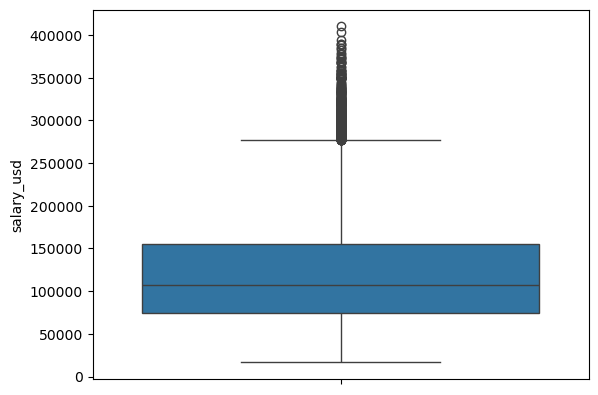

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y=df['salary_usd'])   
plt.show()

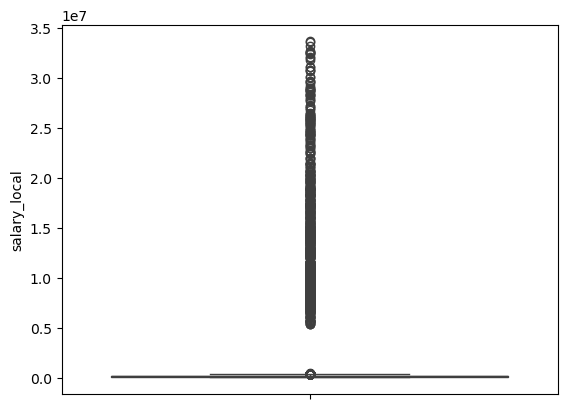

In [26]:
sns.boxplot(y=df['salary_local'])   
plt.show()

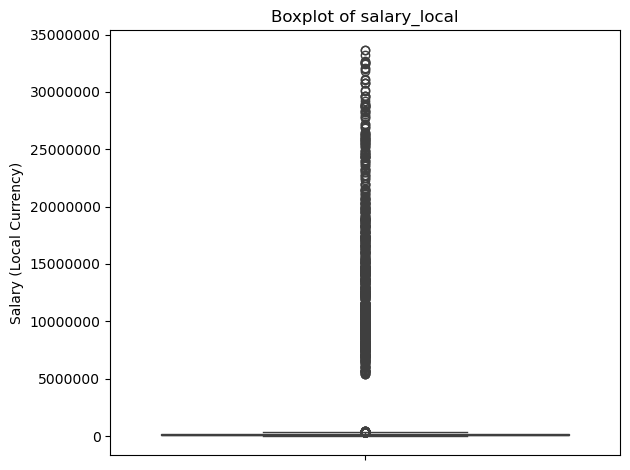

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y=df['salary_local'])

# Disable scientific notation
plt.ticklabel_format(style='plain', axis='y')

plt.title("Boxplot of salary_local")
plt.ylabel("Salary (Local Currency)")
plt.tight_layout()
plt.show()

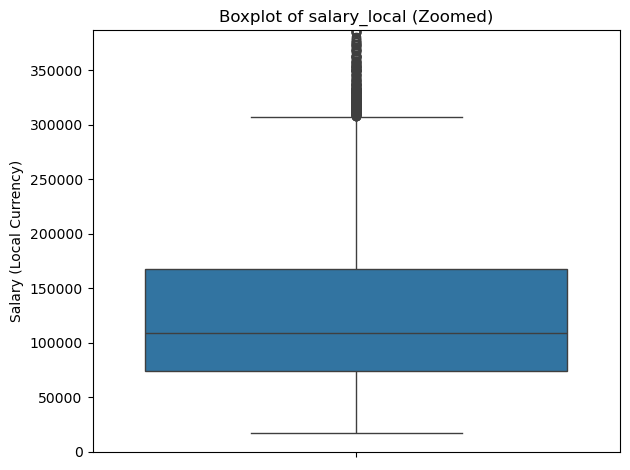

In [28]:
# Zoom in on the middle 95% (without dropping data):
sns.boxplot(y=df['salary_local'])
plt.ylim(0, df['salary_local'].quantile(0.95))  # show up to 95th percentile(lim=limit)
plt.title("Boxplot of salary_local (Zoomed)")
plt.ylabel("Salary (Local Currency)")
plt.tight_layout()
plt.show()


# Remove extreme outliers temporarily to analyze the core data:

Inter Quatrile Range: 93497.0
upper boundary: 307573.25
lower boundary: -66414.75


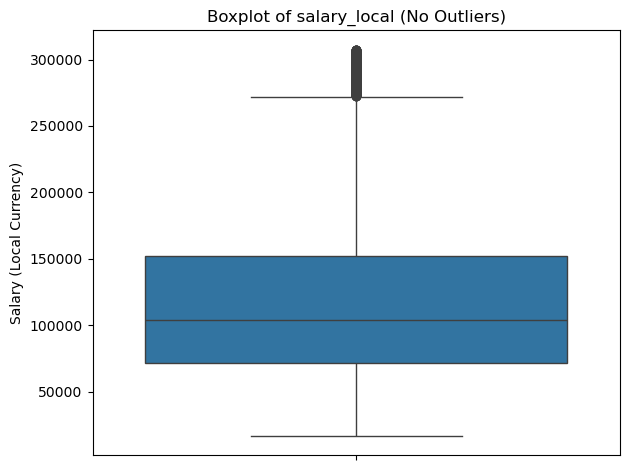

In [29]:
q1 = df['salary_local'].quantile(0.25)
q3 = df['salary_local'].quantile(0.75)
iqr = q3 - q1
print('Inter Quatrile Range:',iqr)

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr
print('upper boundary:',upper)
print('lower boundary:',lower)

# Filter out outliers
filtered = df[(df['salary_local'] >= lower) & (df['salary_local'] <= upper)]


# Plot without outliers
sns.boxplot(y=filtered['salary_local'])
plt.title("Boxplot of salary_local (No Outliers)")
plt.ylabel("Salary (Local Currency)")
plt.tight_layout()
plt.show()

In [30]:
query = "SELECT * FROM job_dataset"
df = pd.read_sql(query, engine)
df

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,AI Product Manager,39171,USD,39171,MI,CT,China,M,China,50,"Azure, R, NLP, Docker, Computer Vision",PhD,4,Consulting,2025-01-07,2025-02-07,1107,5.2,Smart Analytics
14996,AI14997,AI Product Manager,77555,EUR,65922,EN,CT,Netherlands,M,Netherlands,50,"Python, TensorFlow, Mathematics, AWS, Computer...",PhD,0,Energy,2024-12-22,2025-02-12,1870,9.7,Autonomous Tech
14997,AI14998,Data Engineer,28380,USD,28380,EN,FL,India,M,India,50,"Azure, Kubernetes, Spark, Statistics, MLOps",Associate,1,Government,2024-05-04,2024-05-21,1558,9.0,Digital Transformation LLC
14998,AI14999,AI Specialist,58764,EUR,49949,EN,PT,France,M,France,100,"MLOps, Statistics, Data Visualization, R, Python",Master,0,Real Estate,2024-05-08,2024-06-22,546,8.4,Machine Intelligence Group


In [31]:
query = "SELECT * FROM job_dataset"
df = pd.read_sql(query, engine)
df

,job_id,job_title,salary_usd,salary_currency,salary_local,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,Data Scientist,219728,USD,219728,EX,PT,Sweden,M,Sweden,0,"Python, Computer Vision, R, Docker",Associate,13,Transportation,2024-09-23,2024-10-31,1132,6.6,TechCorp Inc
1,AI00002,Head of AI,230237,JPY,25326070,EX,PT,Japan,L,Japan,50,"Kubernetes, MLOps, Tableau, Python",Bachelor,10,Transportation,2024-07-26,2024-09-12,2299,8.5,Cloud AI Solutions
2,AI00003,Data Engineer,128890,EUR,109557,EX,CT,Germany,S,Germany,100,"Spark, Scala, Hadoop, PyTorch, GCP",Bachelor,12,Automotive,2025-01-19,2025-03-28,1329,5.5,Quantum Computing Inc
3,AI00004,Computer Vision Engineer,96349,USD,96349,MI,FL,Finland,L,Finland,50,"MLOps, Linux, Tableau, Python",PhD,2,Automotive,2024-07-20,2024-09-06,1132,6.8,Cognitive Computing
4,AI00005,Robotics Engineer,63065,EUR,53605,EN,FT,France,S,France,100,"R, Scala, SQL, GCP, Python",Associate,0,Finance,2025-03-16,2025-05-09,2011,9.3,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,AI Product Manager,39171,USD,39171,MI,CT,China,M,China,50,"Azure, R, NLP, Docker, Computer Vision",PhD,4,Consulting,2025-01-07,2025-02-07,1107,5.2,Smart Analytics
14996,AI14997,AI Product Manager,77555,EUR,65922,EN,CT,Netherlands,M,Netherlands,50,"Python, TensorFlow, Mathematics, AWS, Computer...",PhD,0,Energy,2024-12-22,2025-02-12,1870,9.7,Autonomous Tech
14997,AI14998,Data Engineer,28380,USD,28380,EN,FL,India,M,India,50,"Azure, Kubernetes, Spark, Statistics, MLOps",Associate,1,Government,2024-05-04,2024-05-21,1558,9.0,Digital Transformation LLC
14998,AI14999,AI Specialist,58764,EUR,49949,EN,PT,France,M,France,100,"MLOps, Statistics, Data Visualization, R, Python",Master,0,Real Estate,2024-05-08,2024-06-22,546,8.4,Machine Intelligence Group


In [32]:
df_sp = pd.read_sql("CALL analyze_job_market();", engine)
df_sp

,job_title,avg_salary_title
0,Data Engineer,127533.77
1,AI Product Manager,126029.68
2,Deep Learning Engineer,124395.49
3,ML Ops Engineer,123466.61
4,NLP Engineer,122867.78
5,Data Scientist,122846.25
6,Machine Learning Researcher,122553.72
7,Machine Learning Engineer,122516.21
8,Research Scientist,122298.95
9,AI Architect,122053.60


In [33]:
import pandas as pd

# Raw DBAPI connection
conn = engine.raw_connection()
cursor = conn.cursor()

# Call the stored procedure
cursor.callproc("analyze_job_market")

# Fetch all result sets manually
dfs = []
while True:
    result = cursor.fetchall()
    if result:
        # Get column names
        columns = [col[0] for col in cursor.description]
        # Create DataFrame
        df = pd.DataFrame(result, columns=columns)
        dfs.append(df)
    if not cursor.nextset():
        break

# Close connection
cursor.close()
conn.close()

# Unpack DataFrames (assuming 6)
(df_title_salary,
 df_country_salary,
 df_jobs_by_company,
 df_jobs_by_industry,
 df_remote_vs_onsite,
 df_exp_level) = dfs


In [34]:
print("1. Top 10 Highest-Paying Job Titles:")
print(df_title_salary)

print("\n2. Countries with Highest Average Salary:")
print(df_country_salary)

print("\n3. Number of Jobs Listed by Each Company:")
print(df_jobs_by_company)

print("\n4. Number of Jobs Posted per Industry:")
print(df_jobs_by_industry)

print("\n5. Remote vs On-site Jobs Count:")
print(df_remote_vs_onsite)

print("\n6. Experience Levels with Most Job Postings:")
print(df_exp_level)


1. Top 10 Highest-Paying Job Titles:
                     job_title avg_salary_title
0                Data Engineer        127533.77
1           AI Product Manager        126029.68
2       Deep Learning Engineer        124395.49
3              ML Ops Engineer        123466.61
4                 NLP Engineer        122867.78
5               Data Scientist        122846.25
6  Machine Learning Researcher        122553.72
7    Machine Learning Engineer        122516.21
8           Research Scientist        122298.95
9                 AI Architect        122053.60

2. Countries with Highest Average Salary:
  company_location avg_salary_country
0      Switzerland          172995.24
1           Norway          161036.84
2          Denmark          158599.66
3    United States          141987.25
4            Japan          131289.03
5      Netherlands          130924.21
6   United Kingdom          130063.90
7        Singapore          129558.32
8        Australia          125719.94
9          I

# 1. Top 10 Highest-Paying Job Titles

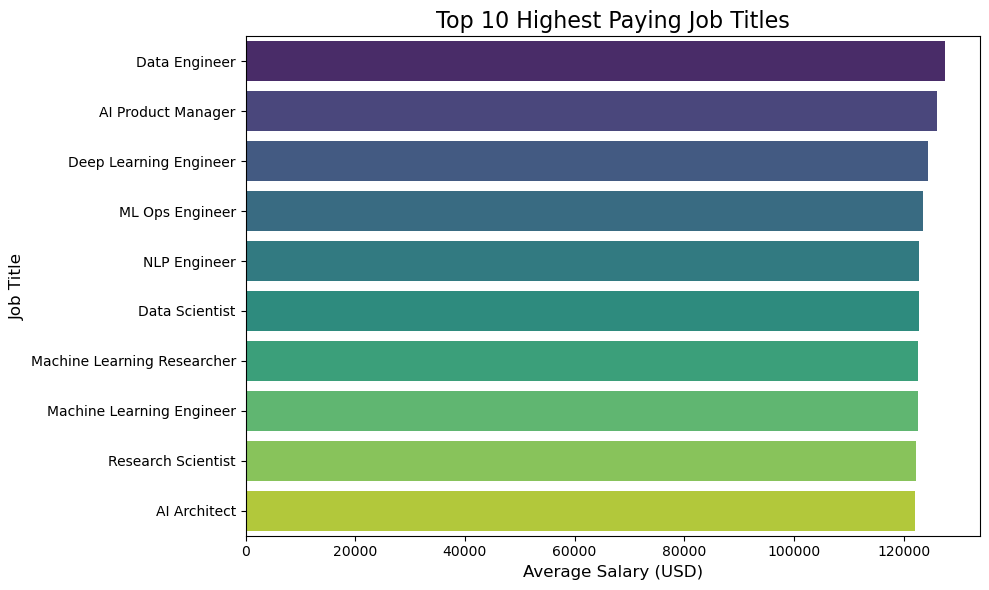

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    x='avg_salary_title', 
    y='job_title', 
    data=df_title_salary, 
    hue='job_title',           # Set hue to avoid future warning
    palette='viridis', 
    legend=False               # Remove redundant legend
)

plt.title('Top 10 Highest Paying Job Titles', fontsize=16)
plt.xlabel('Average Salary (USD)', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.tight_layout()
plt.show()


# 2. Countries with Highest Average Salary

C:\Users\user\AppData\Local\Temp\ipykernel_3340\412316915.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='company_location', y='avg_salary_country', data=df_country_salary, palette='coolwarm')


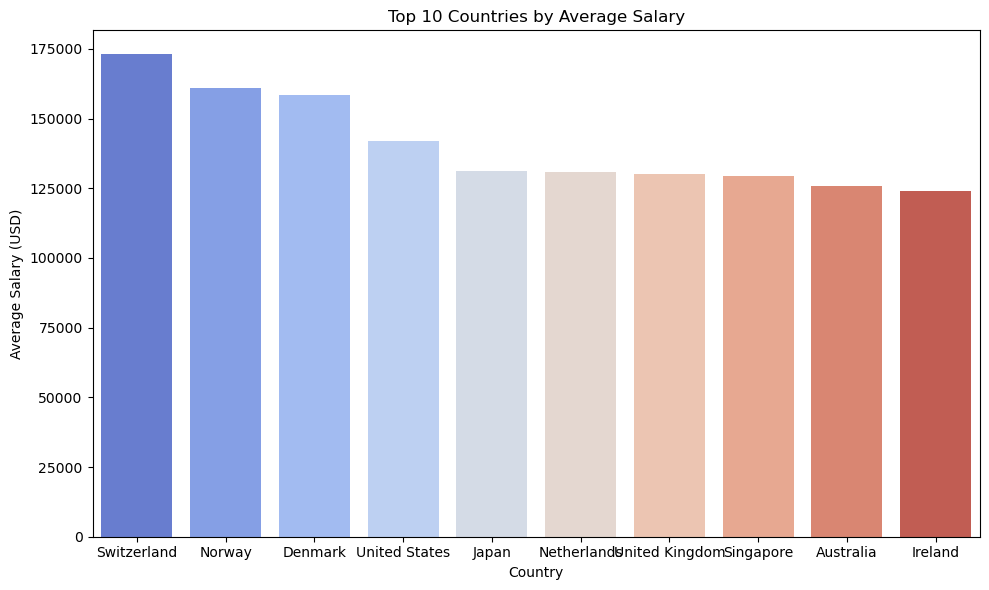

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(x='company_location', y='avg_salary_country', data=df_country_salary, palette='coolwarm')
plt.title('Top 10 Countries by Average Salary')
plt.xlabel('Country')
plt.ylabel('Average Salary (USD)')
plt.tight_layout()
plt.show()


# 3. Number of Jobs Listed by Each Company

C:\Users\user\AppData\Local\Temp\ipykernel_3340\926577404.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='job_postings', y='company_name', data=df_jobs_by_company, palette='cubehelix')


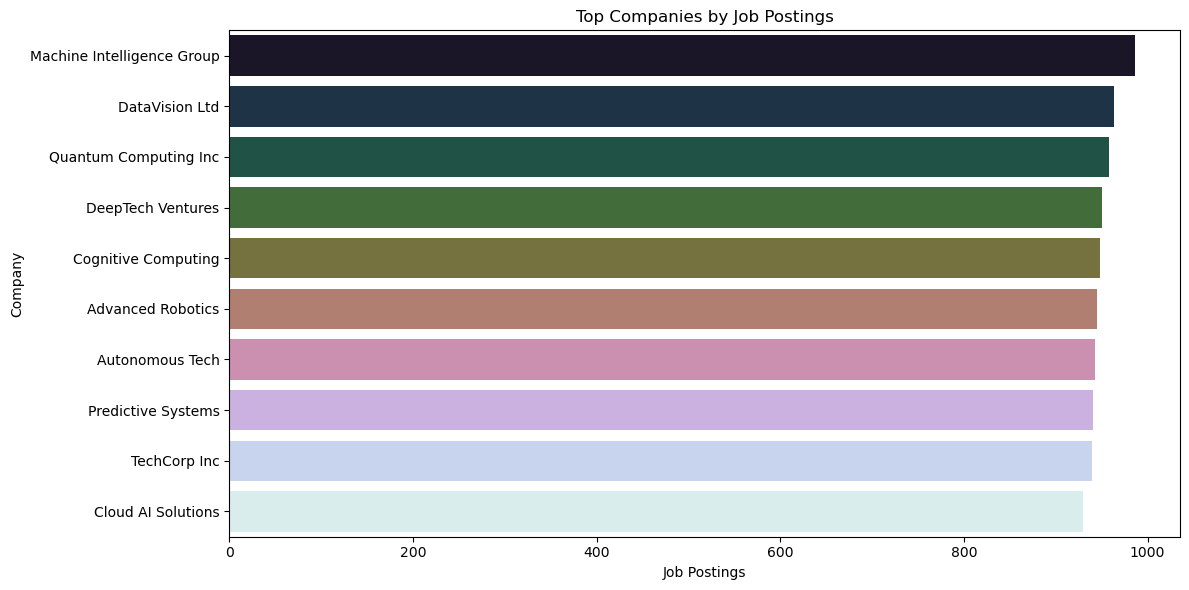

In [37]:
plt.figure(figsize=(12, 6))
sns.barplot(x='job_postings', y='company_name', data=df_jobs_by_company, palette='cubehelix')
plt.title('Top Companies by Job Postings')
plt.xlabel('Job Postings')
plt.ylabel('Company')
plt.tight_layout()
plt.show()


# 4. Jobs Posted per Industry

In [38]:
query = """
SELECT industry, COUNT(*) AS total_jobs 
FROM job_dataset 
GROUP BY industry 
ORDER BY total_jobs DESC;
"""
df_industry_jobs = pd.read_sql(query, engine)


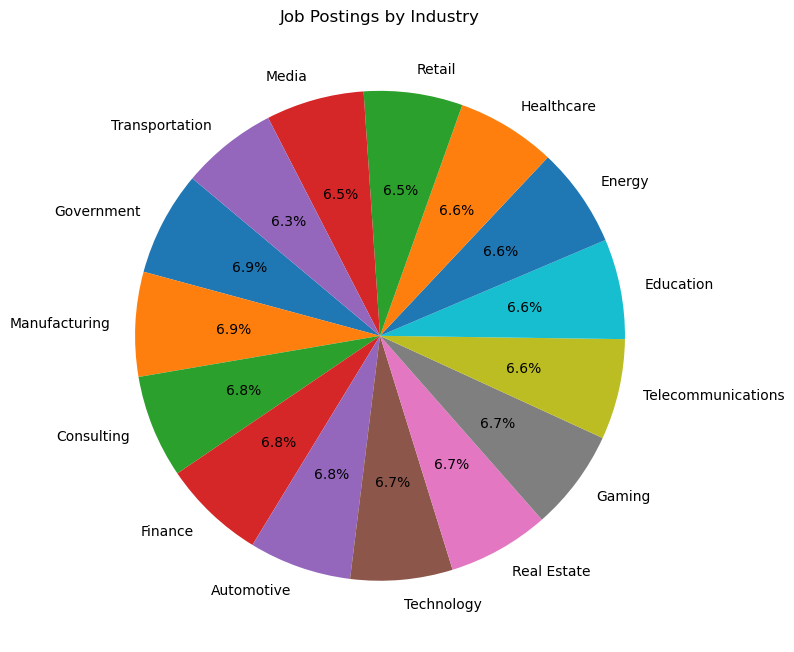

In [39]:
plt.figure(figsize=(8, 8))
plt.pie(df_industry_jobs['total_jobs'], labels=df_industry_jobs['industry'], autopct='%1.1f%%', startangle=140)
plt.title('Job Postings by Industry')
plt.tight_layout()
plt.show()


# 5. Remote vs On-site vs Hybrid Jobs

C:\Users\user\AppData\Local\Temp\ipykernel_3340\398052490.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='work_type', y='job_count', data=df_remote_vs_onsite, palette='Set2')


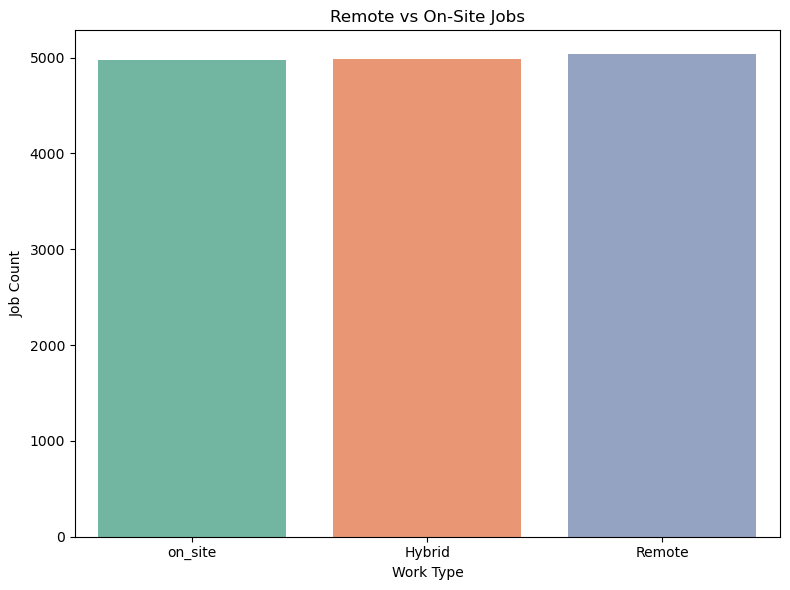

In [40]:
plt.figure(figsize=(8, 6))
sns.barplot(x='work_type', y='job_count', data=df_remote_vs_onsite, palette='Set2')
plt.title('Remote vs On-Site Jobs')
plt.xlabel('Work Type')
plt.ylabel('Job Count')
plt.tight_layout()
plt.show()


#  6. Experience Levels with Most Job Postings

C:\Users\user\AppData\Local\Temp\ipykernel_3340\3008894404.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experience_level', y='num_postings', data=df_exp_level, palette='Accent')


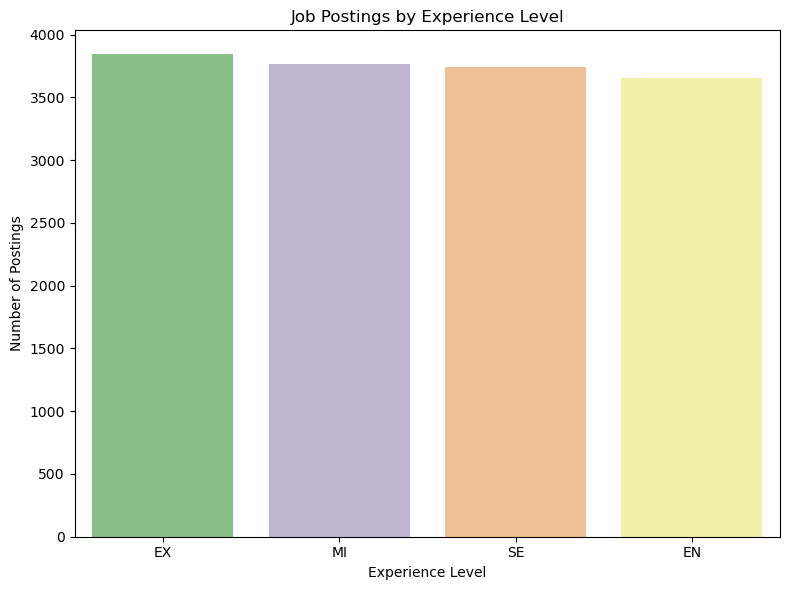

In [41]:
plt.figure(figsize=(8, 6))
sns.barplot(x='experience_level', y='num_postings', data=df_exp_level, palette='Accent')
plt.title('Job Postings by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Number of Postings')
plt.tight_layout()
plt.show()
